# Claude eval — per-sample inspection

Reads the append-only prediction store written by `scripts/claude_eval.py`
(`artifacts/_claude_eval/<run_name>/predictions.jsonl`). Re-run the cells after
you send more samples — the store accumulates and is never re-sent.

Workflow:
```bash
export ANTHROPIC_API_KEY=sk-ant-...
uv run python scripts/claude_eval.py test_per_category=2   # then inspect here
uv run python scripts/claude_eval.py test_per_category=5   # sends only +3/class
```

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
eval_dir = ROOT / "artifacts" / "_claude_eval"
stores = sorted(eval_dir.glob("*/predictions.jsonl"))
print("Available prediction stores:")
for s in stores:
    n = sum(1 for _ in s.open())
    print(f"  [{n:4d} preds]  {s.parent.name}")

# Pick a store (defaults to the most recently modified one).
STORE = max(stores, key=lambda p: p.stat().st_mtime) if stores else None
print("\nUsing:", STORE.parent.name if STORE else "(none — run scripts/claude_eval.py first)")

Available prediction stores:
  [ 200 preds]  claude_sonnet_zero_shot_v1_n0_summary0.25_20ng

Using: claude_sonnet_zero_shot_v1_n0_summary0.25_20ng


In [16]:
df = pd.DataFrame(json.loads(line) for line in STORE.open() if line.strip())
tn_path = STORE.parent / "target_names.json"
target_names = json.loads(tn_path.read_text()) if tn_path.exists() else sorted(df["true_label"].unique())
print(f"{len(df)} predictions across {df['true_label'].nunique()} / {len(target_names)} classes")
print(f"fraction(s): {sorted(df['fraction'].unique())}   few_shot_n: {sorted(df['few_shot_n'].unique())}")
df.head()

200 predictions across 20 / 20 classes
fraction(s): [np.float64(0.25)]   few_shot_n: [np.int64(0)]


,test_idx,doc_sha1,true_idx,true_label,pred_label,pred_idx,correct,summary,source_words,summary_words,fraction,few_shot_n
0,58,0a81e631359321c2,4,comp.sys.mac.hardware,comp.sys.mac.hardware,4.0,True,"ImageWriter LQ discontinued, no AppleTalk 11x1...",17,9,0.25,0
1,156,606cc8d93439524f,6,misc.forsale,misc.forsale,6.0,True,"Minolta FD 50mm lens for sale, $30.",11,7,0.25,0
2,164,69a7e7f0ea82cc7a,8,rec.motorcycles,rec.motorcycles,8.0,True,Can a generator attached to FZJRR11000KRX boos...,59,12,0.25,0
3,283,d04b8fb07bfe9cd5,12,sci.electronics,comp.graphics,1.0,False,Looking to build cheap low-resolution video pr...,17,8,0.25,0
4,389,a6d4b1ff9a5c5576,18,talk.politics.misc,talk.politics.guns,16.0,False,Koresh and followers engaged in gun battle at ...,79,18,0.25,0


## Coverage — how many samples per class so far

In [17]:
cov = (df.groupby("true_label")
         .agg(n=("test_idx", "size"),
              correct=("correct", "sum"),
              unparseable=("pred_idx", lambda s: s.isna().sum()))
         .reindex(target_names, fill_value=0))
cov["acc"] = (cov["correct"] / cov["n"]).round(3)
cov

,n,correct,unparseable,acc
true_label,,,,
alt.atheism,10,4,0,0.4
comp.graphics,10,10,0,1.0
comp.os.ms-windows.misc,10,8,0,0.8
comp.sys.ibm.pc.hardware,10,7,0,0.7
comp.sys.mac.hardware,10,6,0,0.6
comp.windows.x,10,8,0,0.8
misc.forsale,10,8,0,0.8
rec.autos,10,9,0,0.9
rec.motorcycles,10,5,0,0.5


## Aggregate metrics (parseable predictions only)

In [18]:
scored = df[df["pred_idx"].notna()].copy()
scored["pred_idx"] = scored["pred_idx"].astype(int)
y_true, y_pred = scored["true_idx"].to_numpy(), scored["pred_idx"].to_numpy()
n_unparseable = int(df["pred_idx"].isna().sum())

print(f"scored {len(scored)}/{len(df)}   unparseable={n_unparseable}")
print(f"accuracy   = {accuracy_score(y_true, y_pred):.4f}")
print(f"f1_macro   = {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"f1_weighted= {f1_score(y_true, y_pred, average='weighted'):.4f}")
print()
labels_present = sorted(set(y_true) | set(y_pred))
print(classification_report(y_true, y_pred, labels=labels_present,
                            target_names=[target_names[i] for i in labels_present],
                            zero_division=0))

scored 199/200   unparseable=1
accuracy   = 0.7085
f1_macro   = 0.7261
f1_weighted= 0.7257

                          precision    recall  f1-score   support

             alt.atheism       0.80      0.40      0.53        10
           comp.graphics       0.59      1.00      0.74        10
 comp.os.ms-windows.misc       0.80      0.80      0.80        10
comp.sys.ibm.pc.hardware       0.78      0.70      0.74        10
   comp.sys.mac.hardware       1.00      0.60      0.75        10
          comp.windows.x       1.00      0.80      0.89        10
            misc.forsale       0.80      0.80      0.80        10
               rec.autos       0.82      0.90      0.86        10
         rec.motorcycles       1.00      0.50      0.67        10
      rec.sport.baseball       1.00      1.00      1.00        10
        rec.sport.hockey       1.00      0.80      0.89        10
               sci.crypt       0.80      0.80      0.80        10
         sci.electronics       0.83      0.50    

## Confusion matrix

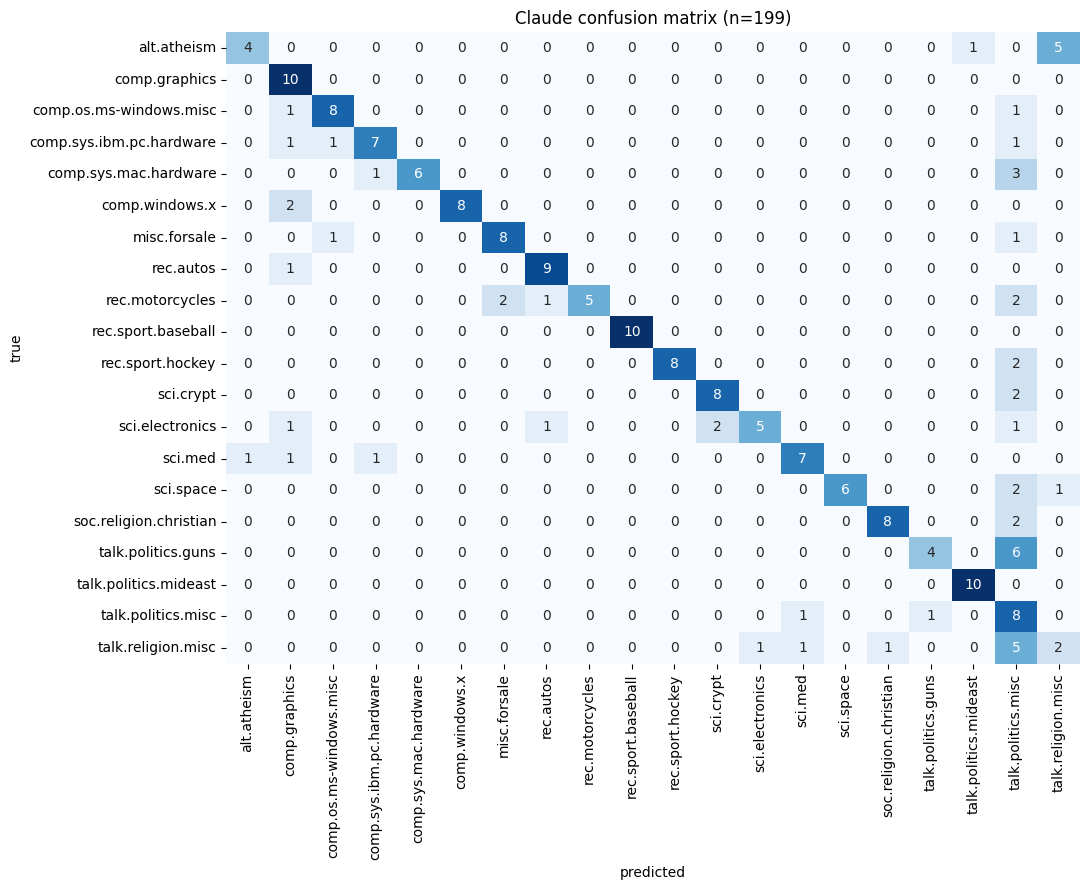

In [19]:
labels = list(range(len(target_names)))
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Claude confusion matrix (n={len(scored)})")
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## Inspect misclassifications

The summary text Claude actually classified is stored per-sample, so you can see
*why* it went wrong.

In [20]:
wrong = df[df["correct"] == False]
print(f"{len(wrong)} misclassified")
with pd.option_context("display.max_colwidth", 200):
    display(wrong[["test_idx", "true_label", "pred_label", "summary_words", "summary"]]
            .reset_index(drop=True))

58 misclassified


,test_idx,true_label,pred_label,summary_words,summary
0,283,sci.electronics,comp.graphics,8,Looking to build cheap low-resolution video projector DIY.
1,389,talk.politics.misc,talk.politics.guns,18,Koresh and followers engaged in gun battle at Mt Carmel; acquittal followed inability to establish who fired first.
2,422,talk.religion.misc,soc.religion.christian,17,"Jesus stated he didn't break Jewish laws, meaning Christians should observe Saturday, not Sunday, as holy day."
3,1030,sci.crypt,talk.politics.misc,8,"Unsurprising news shocks no one, ironic reaction expressed."
4,1228,sci.med,alt.atheism,34,"Responding to recurring sermon about skeptics being closed-minded; argues skeptics use proper methods, reach conclusions without closing minds. Requests evidence for claims, urges open-mindedness,..."
5,1638,sci.space,talk.politics.misc,9,Renting Russian resources for project: would it cause disqualification?
6,1766,talk.religion.misc,sci.med,8,Cockroaches suggested as topic or subject for discussion.
7,2416,comp.sys.ibm.pc.hardware,talk.politics.misc,7,No waffle references found; followups redirected out.
8,2600,comp.os.ms-windows.misc,talk.politics.misc,10,Please share the Usenet post you'd like me to summarize.
9,2961,alt.atheism,talk.religion.misc,39,Mormon archeology grants were given to archeologists to prove Native Americans are the lost tribe of Israel and validate BOM claims of steel-using civilizations in North America. Archeologists acc...


In [21]:
# Unparseable responses (model didn't return a valid category), if any.
bad = df[df["pred_idx"].isna()]
print(f"{len(bad)} unparseable")
with pd.option_context("display.max_colwidth", 200):
    display(bad[["test_idx", "true_label", "pred_label", "summary"]].reset_index(drop=True))

1 unparseable


,test_idx,true_label,pred_label,summary
0,660,sci.space,NaN,New Journal of Experimental Mathematics; Fields medallists on editorial board.
